In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
# Loading the dataset and understanding its structure

df = pd.read_csv("amazonreviews.tsv", sep="\t")

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

df.head()

Dataset Shape: (10000, 2)

Column Names:
Index(['label', 'review'], dtype='object')


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [4]:
# Checking missing values and duplicate records

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
label     0
review    0
dtype: int64

Duplicate Rows: 0


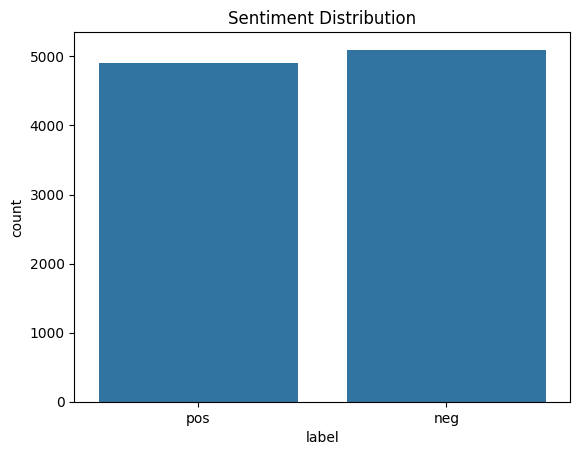

label
neg    5097
pos    4903
Name: count, dtype: int64


In [7]:
# Analyzing sentiment distribution

sns.countplot(data=df, x='label')
plt.title('Sentiment Distribution')
plt.show()

print(df['label'].value_counts())

In [8]:
# Text preprocessing (lowercasing and stopword removal)

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_review'] = df['review'].apply(preprocess_text)

df[['review', 'clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even non-gamer: sound track beautiful!...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything.: reading lot re...
2,Amazing!: This soundtrack is my favorite music...,"amazing!: soundtrack favorite music time, hand..."
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack: truly like soundtrack en...
4,"Remember, Pull Your Jaw Off The Floor After He...","remember, pull jaw floor hearing it: played ga..."


In [9]:
pip install wordcloud

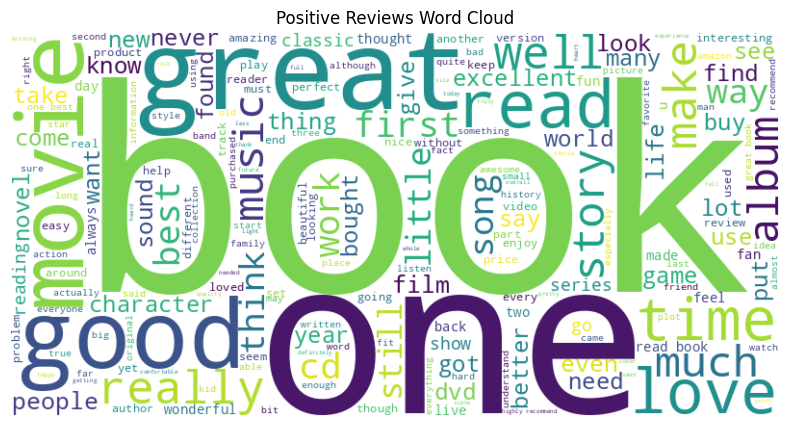

In [10]:
# Generating word cloud for positive reviews

from wordcloud import WordCloud

positive_text = " ".join(df[df['label'] == 'pos']['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews Word Cloud')
plt.show()

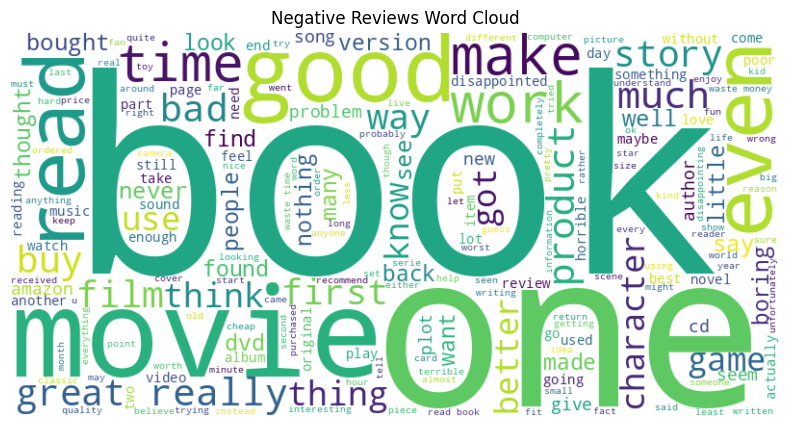

In [11]:
# Generating word cloud for negative reviews

negative_text = " ".join(df[df['label'] == 'neg']['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews Word Cloud')
plt.show()

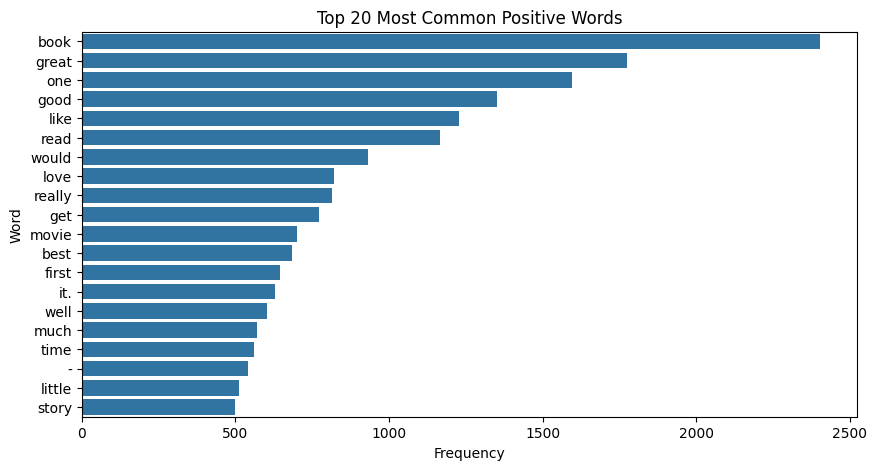

,Word,Frequency
0,book,2403
1,great,1775
2,one,1594
3,good,1353
4,like,1227
5,read,1167
6,would,931
7,love,820
8,really,814
9,get,773


In [12]:
# Finding most common words in positive reviews

from collections import Counter

positive_text = " ".join(df[df['label'] == 'pos']['clean_review'])

positive_words = positive_text.split()

positive_word_freq = Counter(positive_words).most_common(20)

positive_df = pd.DataFrame(positive_word_freq, columns=['Word', 'Frequency'])

plt.figure(figsize=(10,5))
sns.barplot(data=positive_df, x='Frequency', y='Word')
plt.title('Top 20 Most Common Positive Words')
plt.show()

positive_df

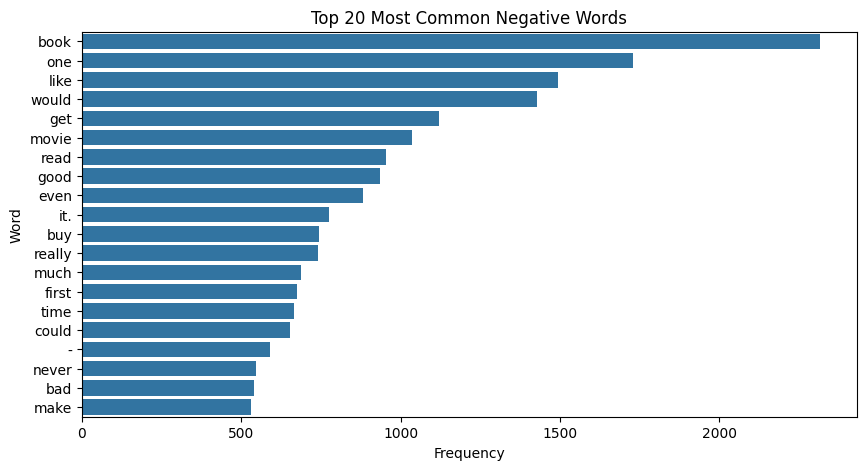

,Word,Frequency
0,book,2316
1,one,1729
2,like,1493
3,would,1427
4,get,1122
5,movie,1036
6,read,954
7,good,934
8,even,882
9,it.,774


In [13]:
# Finding most common words in negative reviews

from collections import Counter

negative_text = " ".join(df[df['label'] == 'neg']['clean_review'])

negative_words = negative_text.split()

negative_word_freq = Counter(negative_words).most_common(20)

negative_df = pd.DataFrame(negative_word_freq, columns=['Word', 'Frequency'])

plt.figure(figsize=(10,5))
sns.barplot(data=negative_df, x='Frequency', y='Word')
plt.title('Top 20 Most Common Negative Words')
plt.show()

negative_df

In [14]:
# Converting sentiment labels into numerical values

df['label'] = df['label'].map({'neg': 0, 'pos': 1})

df['label'].value_counts()

,count
label,
0,5097
1,4903


In [15]:
# Converting text into numerical features using TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])

y = df['label']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (10000, 5000)
Target Shape: (10000,)


In [16]:
# Splitting data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (8000, 5000)
Testing Data Shape: (2000, 5000)


In [17]:
# Training Logistic Regression model

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [18]:
# Making predictions on test data

y_pred = lr_model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 1 1 1 0 0 0]


In [19]:
# Evaluating model performance

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.856
Precision: 0.8534031413612565
Recall   : 0.8463136033229491
F1 Score : 0.8498435870698644


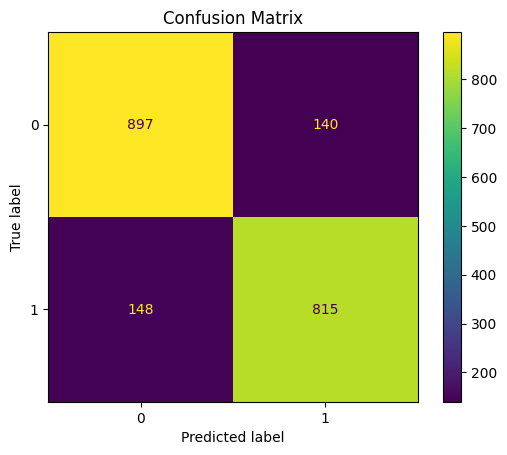

[[897 140]
 [148 815]]


In [20]:
# Creating confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

print(cm)

In [21]:
# Performing 5-Fold Cross Validation

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.8565 0.831  0.827  0.845  0.85  ]
Average CV Accuracy: 0.8418999999999999


**Text Classification and Sentiment Analysis**



**Objective**

The objective of this project is to build a sentiment analysis system that classifies Amazon customer reviews as positive or negative. This helps in understanding customer opinions and improving customer satisfaction.

**Dataset Description**

The dataset contains 10,000 Amazon customer reviews with two columns:

label:      Sentiment of the review (positive or negative)

review: Customer review text

**Data Preprocessing**


The dataset was checked for missing values and duplicate records. No missing values or duplicate records were found. Text preprocessing was performed by converting all reviews to lowercase and removing stopwords. This helped in reducing unnecessary words and improving text quality.

**Exploratory Data Analysis**

Sentiment distribution analysis showed that the dataset is balanced with 4,903 positive reviews and 5,097 negative reviews. Word clouds were generated for positive and negative reviews. The most common positive and negative words were also identified.

**Feature Extraction**

TF-IDF was used to convert review text into numerical features. A maximum of 5,000 features were generated from the review text.

**Model Development**

A Logistic Regression model was used for sentiment classification. The dataset was divided into training data (80%) and testing data (20%) using train-test split.

**Model Evaluation**

The model achieved the following results:

Accuracy: 85.60%

Precision: 85.34%

Recall: 84.63%

F1 Score: 84.98%

Average Cross Validation Accuracy: 84.19%

The confusion matrix showed that the model correctly classified most positive and negative reviews.

**Conclusion**

In this project, a sentiment analysis system was developed using TF-IDF and Logistic Regression. The model achieved an accuracy of 85.60%, indicating good performance in classifying customer reviews. The results show that machine learning techniques can effectively identify customer sentiment from review text and help businesses understand customer feedback.